In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [2]:
X = np.array([
    [1,4, 1.5, 3.8],
    [3,6, 1.0, 3.1],
    [4,7, 0.8, 3.9],
    [5,8, 0.4, 3.4],
    [7,9, 0.2, 2.8]
])
y = np.array([ 45.9 ,  76.55,  92.35, 107.9 , 128.  ])

Text(0, 0.5, 'salary')

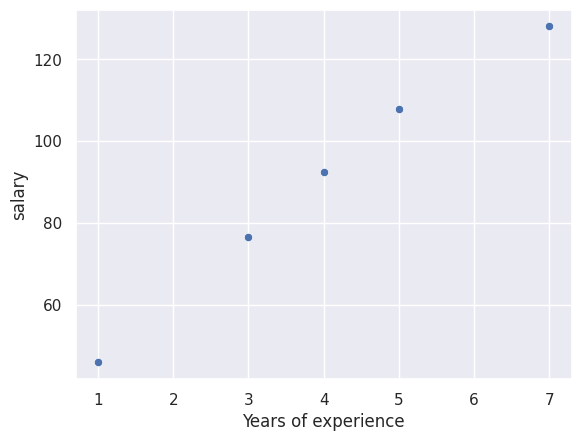

In [3]:
sns.scatterplot(x=X[:,0:1].ravel(),y=y)
plt.xlabel("Years of experience")
plt.ylabel("salary")


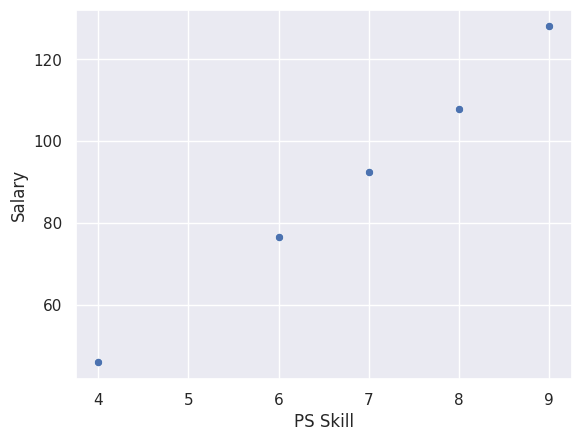

In [4]:
sns.scatterplot(x=X[:,1:2].ravel(), y=y)
plt.xlabel("PS Skill")
plt.ylabel("Salary")
plt.show()

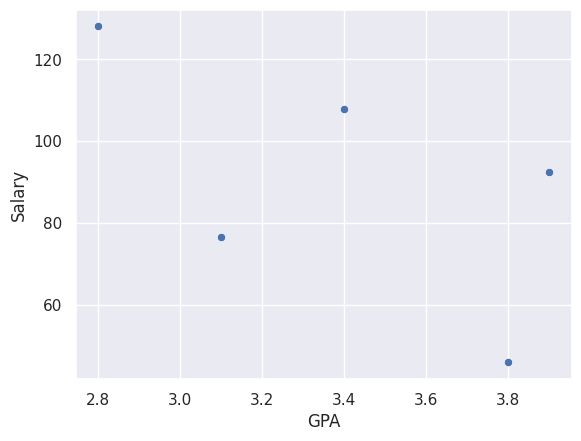

In [5]:
sns.scatterplot(x=X[:,3:].ravel(), y=y)
plt.xlabel("GPA")
plt.ylabel("Salary")
plt.show()

In [6]:
def make_prediction(X,W,b):
  m = X.shape[0]
  pred_list = np.zeros((m,))

  for i in range(m):
    pred_list[i] = np.dot(W,X[i]) + b
  return pred_list

In [7]:
m = X.shape[0]
n = X.shape[1]

W_init = np.ones((n,))
b_init = 1.0

make_prediction(X,W_init, b_init)

array([11.3, 14.1, 16.7, 17.8, 20. ])

In [8]:
def compute_cost(X,y,W,b):
  m = X.shape[0]
  cost = 0.0
  pred_list = make_prediction(X,W,b)
  error = pred_list - y
  error_sq = error**2
  print(error_sq)
  cost = np.sum(error_sq)
  cost = cost/(2*m)
  return cost


In [9]:
compute_cost(X,y,W_init,b_init)

[ 1197.16    3900.0025  5722.9225  8118.01   11664.    ]


np.float64(3060.2095)

In [10]:
def calculate_gradient(X, y, W, b):
  """Computes the gradient (direction to move) for w and b"""
  m = X.shape[0]
  n = X.shape[1]

  dj_dw = np.zeros((n,)) ## jotota feature totota weights
  dj_db = 0.0 # Change needed for bias

  for i in range(m):
    prediction = np.dot(W,X[i]) + b
    error = prediction - y[i]
    dj_db = dj_db + error

    for j in range(n):
      dj_dw[j] =  dj_dw[j]+(error * X[i,j])



  return dj_dw/m, dj_db/m

In [11]:
W_init = np.ones((n,))
b_init = 1.0
calculate_gradient(X,y, W_init ,b_init)

(array([-346.21 , -547.09 ,  -46.502, -245.77 ]), np.float64(-74.16))

# optimization of cost function

In [12]:
def gradient_desccent(X,y,w_input,b_input,max_iter, alpha=0.01):
  W = w_input
  b = b_input
  cost_memory = []
  iter_memory = []

  for i in range(max_iter):
    dj_dw, dj_db = calculate_gradient(X,y,W,b)

    W = W - alpha * dj_dw
    b = b - alpha * dj_db

    cost = compute_cost(X,y,W,b)
    cost_memory.append(cost)
    iter_memory.append(i)

    if i%100==0:
      print(f"{i},.......")
  return W,b,cost_memory, iter_memory



In [13]:
W_init = np.zeros((n,))
b_init = 0.0

w_final, b_final, cost_memo, iter_list = gradient_desccent(X,y,w_input=W_init,b_input=b_init,max_iter=1000, alpha=0.01)


[  4.66059015 186.40140535 269.04745191 524.87946342 899.46871843]
0,.......
[ 40.73425301   1.38447557   1.73900325  35.4646581  106.82900856]
[62.651772    1.57725053  2.69248286  6.52849384 39.61378731]
[64.90594501  2.85214042  4.77933347  3.44485564 28.79393819]
[62.79877523  2.97478587  5.0698157   2.87526244 25.62015465]
[59.94645144  2.83218801  4.94001532  2.69996351 23.85968571]
[57.07081318  2.64665938  4.73446451  2.60072922 22.43028673]
[54.30690717  2.46245904  4.5228101   2.51890755 21.12429884]
[51.67510266  2.28763927  4.31828902  2.44303128 19.89858798]
[49.17375019  2.12324067  4.12306637  2.37074418 18.74181946]
[46.79720747  1.9689804   3.93716903  2.30147648 17.6489589 ]
[44.53932876  1.82434714  3.76022754  2.23501373 16.61633918]
[42.39412894  1.68881024  3.59181431  2.17121601 15.64069884]
[40.35589928  1.56185864  3.43150845  2.10996267 14.71898878]
[38.41921735  1.44300708  3.27890747  2.05114124 13.84832793]
[36.57893697  1.33179618  3.1336287   1.99464501 1

In [14]:
w_final

array([ 6.50734891,  8.7265892 , -0.67145907,  1.36013556])

In [15]:
X_test=  [2,10, 1.5, 3.8]

prediction_of_new_data = w_final[0] * X_test[0] +w_final[1] * X_test[1] + w_final[2] * X_test[2] + w_final[3] * X_test[3] + b_final

print(prediction_of_new_data)

105.11190003056124


Linear Regression using scikit learn
# SGD Regressor

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

In [18]:
model1=LinearRegression()   # using linear regression or using OLS (Ordinary least squared) Gradient Descent
model1.fit(X,y)
print(model1.coef_)
print(model1.intercept_)

[ 5.  10.  -2.   0.5]
2.000000000000142


In [24]:
from ast import Constant
model2 = SGDRegressor(penalty=None,max_iter=1000000000, learning_rate="constant")
model2.fit(X,y)

print(model2.coef_)
print(model2.intercept_)


[ 6.1991402   8.93367446 -0.68394247  1.18315257]
[0.69641513]
